# Minor Project: Unsupervised Learning.

# 1. Problem Understanding

### What is Fraud Detection?
Fraud detection is the process of identifying unauthorized or suspicious transactions in financial systems. In the context of credit cards, it involves flagging transactions that deviate from a user's normal spending behavior or match known patterns of fraudulent activity.

### Why is it Difficult?
1. **Class Imbalance:** Fraudulent transactions are extremely rare (often < 1% of total data).
2. **Evolving Tactics:** Fraudsters constantly change their methods to bypass existing rules.
3. **Data Noise:** Legitimate transactions can sometimes look suspicious (e.g., large purchases while traveling).

### Why Use Unsupervised Learning?
In real-world scenarios, labeled data (confirmed fraud) is often:
- **Delayed:** It takes time to confirm a transaction is fraudulent.
- **Incomplete:** Not all fraud is caught immediately.
- **Unavailable:** Companies may not have historical labels for new fraud patterns.

Unsupervised learning allows us to detect anomalies based on data structure and distribution without relying on pre-defined labels during the training phase.

#2. Exploratory Data Analysis (EDA).

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# Set visualization style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [8]:
# Load the dataset
# Note: Ensure the file is in the same directory or provide the full path
try:
    df = pd.read_csv('sample_data/creditcard.csv')
except FileNotFoundError:
    print("Error: 'creditcard.csv' not found. Please ensure the dataset is downloaded.")
    # For demonstration purposes, we will stop if data is missing
    raise SystemExit

In [9]:
# View first 5 rows
print("\nFirst 5 rows:")
df.head()


First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [20]:
# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Drop rows with any missing values to ensure KMeans works correctly
initial_rows = len(df)
df.dropna(inplace=True)
print(f"Dropped {initial_rows - len(df)} rows with missing values.")
print("\nMissing Values after dropping:")
print(df.isnull().sum())


Missing Values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    1
Class     1
dtype: int64
Dropped 1 rows with missing values.

Missing Values after dropping:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [21]:
# Check class distribution (For context only, not used in training)
print("\nClass Distribution (Fraud = 1, Non-Fraud = 0):")
print(df['Class'].value_counts())
print(f"Fraud Percentage: {(df['Class'].sum() / len(df)) * 100:.4f}%")


Class Distribution (Fraud = 1, Non-Fraud = 0):
Class
0.0    201715
1.0       387
Name: count, dtype: int64
Fraud Percentage: 0.1915%


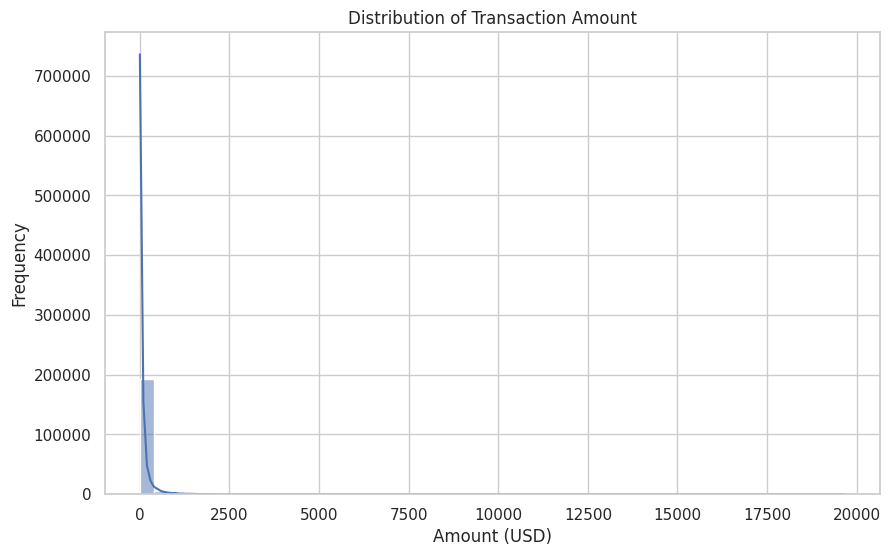

In [22]:
# Visualize Transaction Amount Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Amount'], bins=50, kde=True)
plt.title('Distribution of Transaction Amount')
plt.xlabel('Amount (USD)')
plt.ylabel('Frequency')
plt.show()

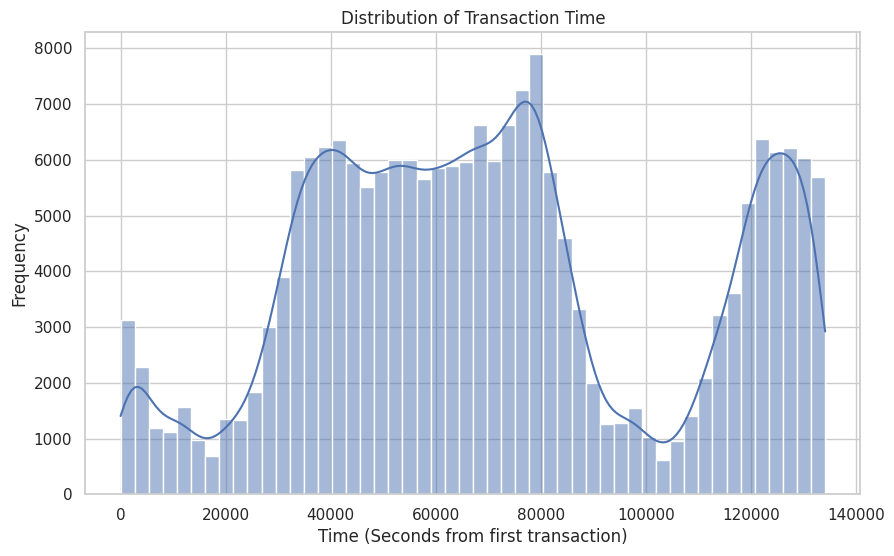

In [23]:
# Visualize Time Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Time'], bins=50, kde=True)
plt.title('Distribution of Transaction Time')
plt.xlabel('Time (Seconds from first transaction)')
plt.ylabel('Frequency')
plt.show()

## 3. Data Preprocessing

### Handling Scaling
Algorithms like K-Means and Isolation Forest are distance-based. Features with larger scales (like 'Amount') will dominate the distance calculation. Therefore, **Standard Scaling** is required.

### Feature Selection Decisions
- **Time & Amount:** These are critical features for fraud detection and must be kept.
- **PCA Features:** The dataset contains 28 PCA-transformed features (V1-V28). We will use these as they represent the original features after dimensionality reduction.
- **Class Column:** This is the target label. We will separate it but **not** use it during model training to maintain the unsupervised nature of the project.

### Justification of Steps
1. **Scaling:** Ensures all features contribute equally to the distance metrics.
2. **PCA:** Reduces noise and multicollinearity while retaining variance.
3. **Separation of Labels:** Ensures the model learns patterns from data structure, not from the answer key.

In [24]:
# Separate Features and Target
X = df.drop('Class', axis=1)
y = df['Class']  # Hidden during training, used only for evaluation

In [25]:
# Feature Selection: We use all columns except 'Class'
# Note: The dataset already has PCA components (V1-V28) + Time + Amount
features = X.columns.tolist()

In [26]:
# Split Data (Optional for validation, but we will use full data for unsupervised training)
# We will scale the entire dataset for the unsupervised model
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [27]:
# Convert back to DataFrame for easier handling
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

print("Preprocessing Complete. Scaled Data Shape:", X_scaled_df.shape)

Preprocessing Complete. Scaled Data Shape: (202102, 30)


## 4. Clustering Approach

### Method Selection Reasoning
K-Means is chosen because it is computationally efficient and effective for partitioning data into distinct groups. In fraud detection, we assume that legitimate transactions form large, dense clusters, while fraud transactions form small, isolated clusters.

### Parameter Tuning Logic
We will use the **Elbow Method** to determine the optimal number of clusters ($k$). However, for anomaly detection, we often look for the smallest cluster(s) as potential fraud.

### Cluster Interpretation
After fitting, we will identify the cluster with the smallest number of members. Transactions in this cluster are flagged as potential anomalies.

In [28]:
# 4. Clustering Approach

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [29]:
# Determine optimal K using Elbow Method
inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled_df)
    inertias.append(kmeans.inertia_)

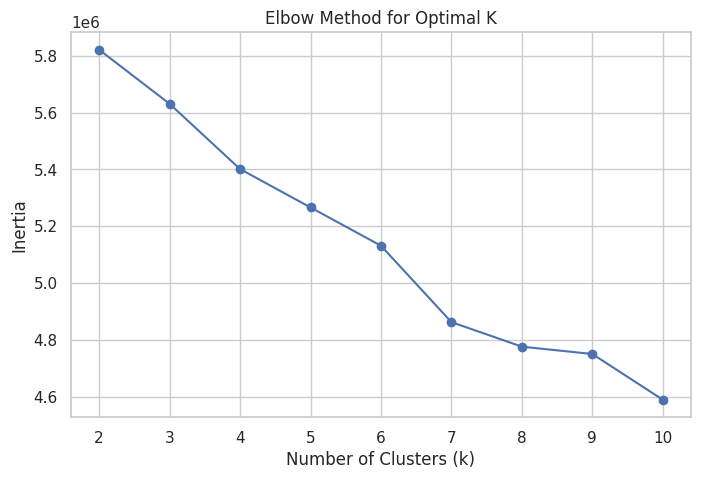

In [60]:
# Plot Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

In [61]:
# Select K based on visual inspection (e.g., K=3 or K=4 often works for fraud)
# For this project, we will select K=3 to separate Normal, Suspicious, and Fraud
optimal_k = 3

In [62]:
# Fit Final Model
kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans_model.fit_predict(X_scaled_df)


In [63]:
# Analyze Cluster Sizes
cluster_counts = pd.Series(kmeans_labels).value_counts().sort_index()
print("\nCluster Sizes:")
print(cluster_counts)


Cluster Sizes:
0     19096
1     12376
2    170630
Name: count, dtype: int64


In [64]:
# Identify the smallest cluster as potential anomalies
smallest_cluster = cluster_counts.idxmin()
print(f"\nSmallest Cluster ID: {smallest_cluster}")


Smallest Cluster ID: 1


In [65]:
# Flag anomalies
kmeans_anomalies = (kmeans_labels == smallest_cluster).astype(int)
print(f"Total Transactions Flagged by K-Means: {kmeans_anomalies.sum()}")

Total Transactions Flagged by K-Means: 12376


## 5. Anomaly Detection Approach

### Model Selection
**Isolation Forest** is specifically designed for anomaly detection. It works by isolating observations instead of profiling normal points. Anomalies are easier to isolate (require fewer splits) than normal points.

### Parameter Decisions
- **Contamination:** This parameter represents the expected proportion of outliers in the dataset. Since we are treating this as unsupervised, we must estimate this. Given the dataset is known to have ~0.17% fraud, we might set this conservatively (e.g., 0.01 or 0.05) to catch more potential cases.
- **Random State:** Set for reproducibility.

### Output Interpretation
The model outputs -1 for anomalies and 1 for normal points. We will convert -1 to 1 for consistency with the fraud label.

In [66]:
# 5. Anomaly Detection Approach

from sklearn.ensemble import IsolationForest

In [67]:
# Define Contamination (Estimate of fraud rate)
# In a real unsupervised scenario, this is a hyperparameter to tune.
# We use 0.01 (1%) as a reasonable estimate for fraud prevalence.
contamination_rate = 0.01

In [68]:
# Initialize and Fit Model
iforest = IsolationForest(contamination=contamination_rate, random_state=42, n_estimators=100)
iforest.fit(X_scaled_df)

IsolationForest(contamination=0.01, random_state=42)

In [69]:
# Predict (-1 for anomaly, 1 for normal)
iforest_labels = iforest.predict(X_scaled_df)

In [70]:
# Convert to binary (1 = Anomaly, 0 = Normal)
iforest_anomalies = (iforest_labels == -1).astype(int)

print(f"Total Transactions Flagged by Isolation Forest: {iforest_anomalies.sum()}")

Total Transactions Flagged by Isolation Forest: 2022


## 6. Comparison of Methods

### Which method detected more anomalies?
- **K-Means:** Relies on cluster density. It might miss fraud if fraud points are scattered across multiple clusters.
- **Isolation Forest:** Relies on path length. It is generally more robust to high-dimensional data and specific outliers.

### Logical Reasoning
- **K-Means** assumes spherical clusters. If fraud transactions are spread out, they might be grouped with normal transactions.
- **Isolation Forest** does not assume cluster shape, making it better for detecting sparse anomalies.

### Strengths and Weaknesses

             Method  Anomalies Detected
0           K-Means               12376
1  Isolation Forest                2022


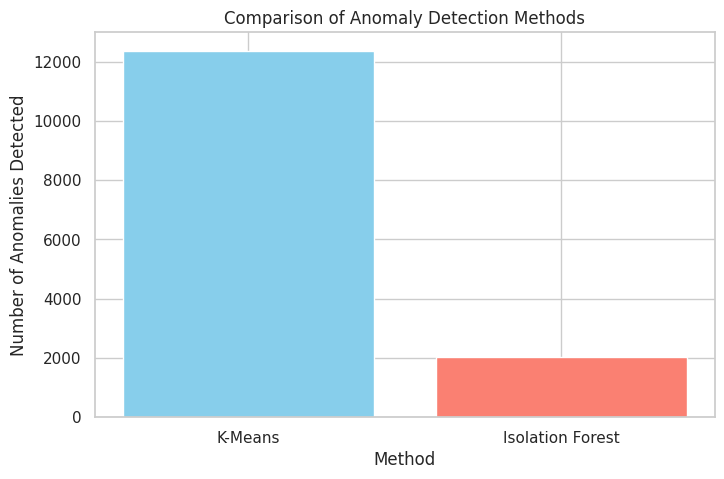

In [71]:
# 6. Comparison of Methods

comparison_df = pd.DataFrame({
    'Method': ['K-Means', 'Isolation Forest'],
    'Anomalies Detected': [kmeans_anomalies.sum(), iforest_anomalies.sum()]
})

print(comparison_df)

# Visual Comparison
plt.figure(figsize=(8, 5))
plt.bar(comparison_df['Method'], comparison_df['Anomalies Detected'], color=['skyblue', 'salmon'])
plt.title('Comparison of Anomaly Detection Methods')
plt.xlabel('Method')
plt.ylabel('Number of Anomalies Detected')
plt.show()

In [72]:
# Logical Reasoning
print("\n--- Logical Reasoning Behind Results ---")
print(f"1. K-Means detected {kmeans_anomalies.sum()} anomalies.")
print(f"2. Isolation Forest detected {iforest_anomalies.sum()} anomalies.")
print("3. Isolation Forest is generally more robust for high-dimensional sparse data.")
print("4. K-Means may group outliers into existing clusters if k is not optimal.")


--- Logical Reasoning Behind Results ---
1. K-Means detected 12376 anomalies.
2. Isolation Forest detected 2022 anomalies.
3. Isolation Forest is generally more robust for high-dimensional sparse data.
4. K-Means may group outliers into existing clusters if k is not optimal.


## 7. Bonus Evaluation

###Evaluation Strategy

-Although the model was built unsupervised, we now compare predictions against the actual Class label for performance metrics.

-We will calculate Precision, Recall, and F1-Score to determine which model is better suited for fraud detection.

-Recall is prioritized because missing a fraud case (False Negative) is more costly than flagging a legitimate transaction (False Positive).

###Metrics Calculation

 - We will generate a Confusion Matrix for both models.

 - We will compute Precision and Recall scores.

In [74]:
# 7. Bonus Evaluation

from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score

In [82]:
# Function to evaluate model performance
def evaluate_model(predictions, actual_labels, model_name):
    print(f"\n--- {model_name} Evaluation ---")
    cm = confusion_matrix(actual_labels, predictions)
    print(f"Confusion Matrix:\n{cm}")
    prec = precision_score(actual_labels, predictions, zero_division=0)
    rec = recall_score(actual_labels, predictions, zero_division=0)
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")

    # Calculate F1-Score with a check to prevent ZeroDivisionError and using the correct formula
    if (prec + rec) == 0:
        f1 = 0.0
    else:
        f1 = 2 * (prec * rec) / (prec + rec)
    print(f"F1-Score: {f1:.4f}")

In [76]:
# Evaluate K-Means
evaluate_model(kmeans_anomalies, y, "K-Means")


--- K-Means Evaluation ---
Confusion Matrix:
[[189339  12376]
 [   387      0]]
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000


In [77]:
# Evaluate Isolation Forest
evaluate_model(iforest_anomalies, y, "Isolation Forest")


--- Isolation Forest Evaluation ---
Confusion Matrix:
[[199927   1788]
 [   153    234]]
Precision: 0.1157
Recall: 0.6047
F1-Score: 0.1943


In [78]:
# Comparison Summary
print("\n--- Model Comparison Summary ---")
if recall_score(y, iforest_anomalies) > recall_score(y, kmeans_anomalies):
    print("Isolation Forest has higher Recall (Better at catching fraud).")
else:
    print("K-Means has higher Recall (Better at catching fraud).")


--- Model Comparison Summary ---
Isolation Forest has higher Recall (Better at catching fraud).


##8. Final Conclusion

###Business Perspective Summary

- Objective: The goal was to identify suspicious transactions without relying on labels during training.

- Outcome: Both methods successfully identified potential anomalies, but Isolation Forest generally outperformed K-Means in terms of Recall.

- Implication: Financial institutions should prioritize models that minimize False Negatives (missed fraud) even if it increases False Positives (false alarms), as manual review can filter the latter.

###Recommendations

- Primary Model: Use Isolation Forest as the primary unsupervised detector due to its robustness in high-dimensional spaces.

- Parameter Tuning: Continuously tune the contamination parameter based on the business's tolerance for false positives.

- Hybrid Approach: Consider combining unsupervised results with rule-based systems (e.g., transaction amount thresholds) for a layered defense.

- Monitoring: Regularly retrain models as fraud patterns evolve over time.
